# Hotel Booking Cancellation Prediction - EDA

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("/notebooks/ML/Hotel Booking Cancellation Prediction/datasets/hotel_bookings.csv")

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.shape

(119390, 32)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
column_names = df.columns.tolist()
numerical_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

## Basic EDA

### Statistical summary

In [8]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Checking for null values

In [9]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

### Class distribution

In [10]:
print("Class distribution")
print(df['is_canceled'].value_counts())

Class distribution
is_canceled
0    75166
1    44224
Name: count, dtype: int64


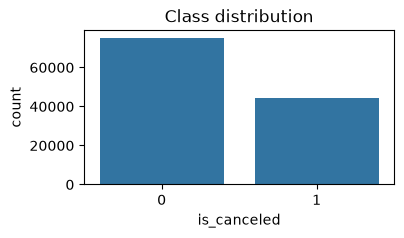

In [11]:
plt.figure(figsize=(4, 2))
sns.countplot(x=df['is_canceled'])
plt.title("Class distribution")
plt.show()

### Data distribution

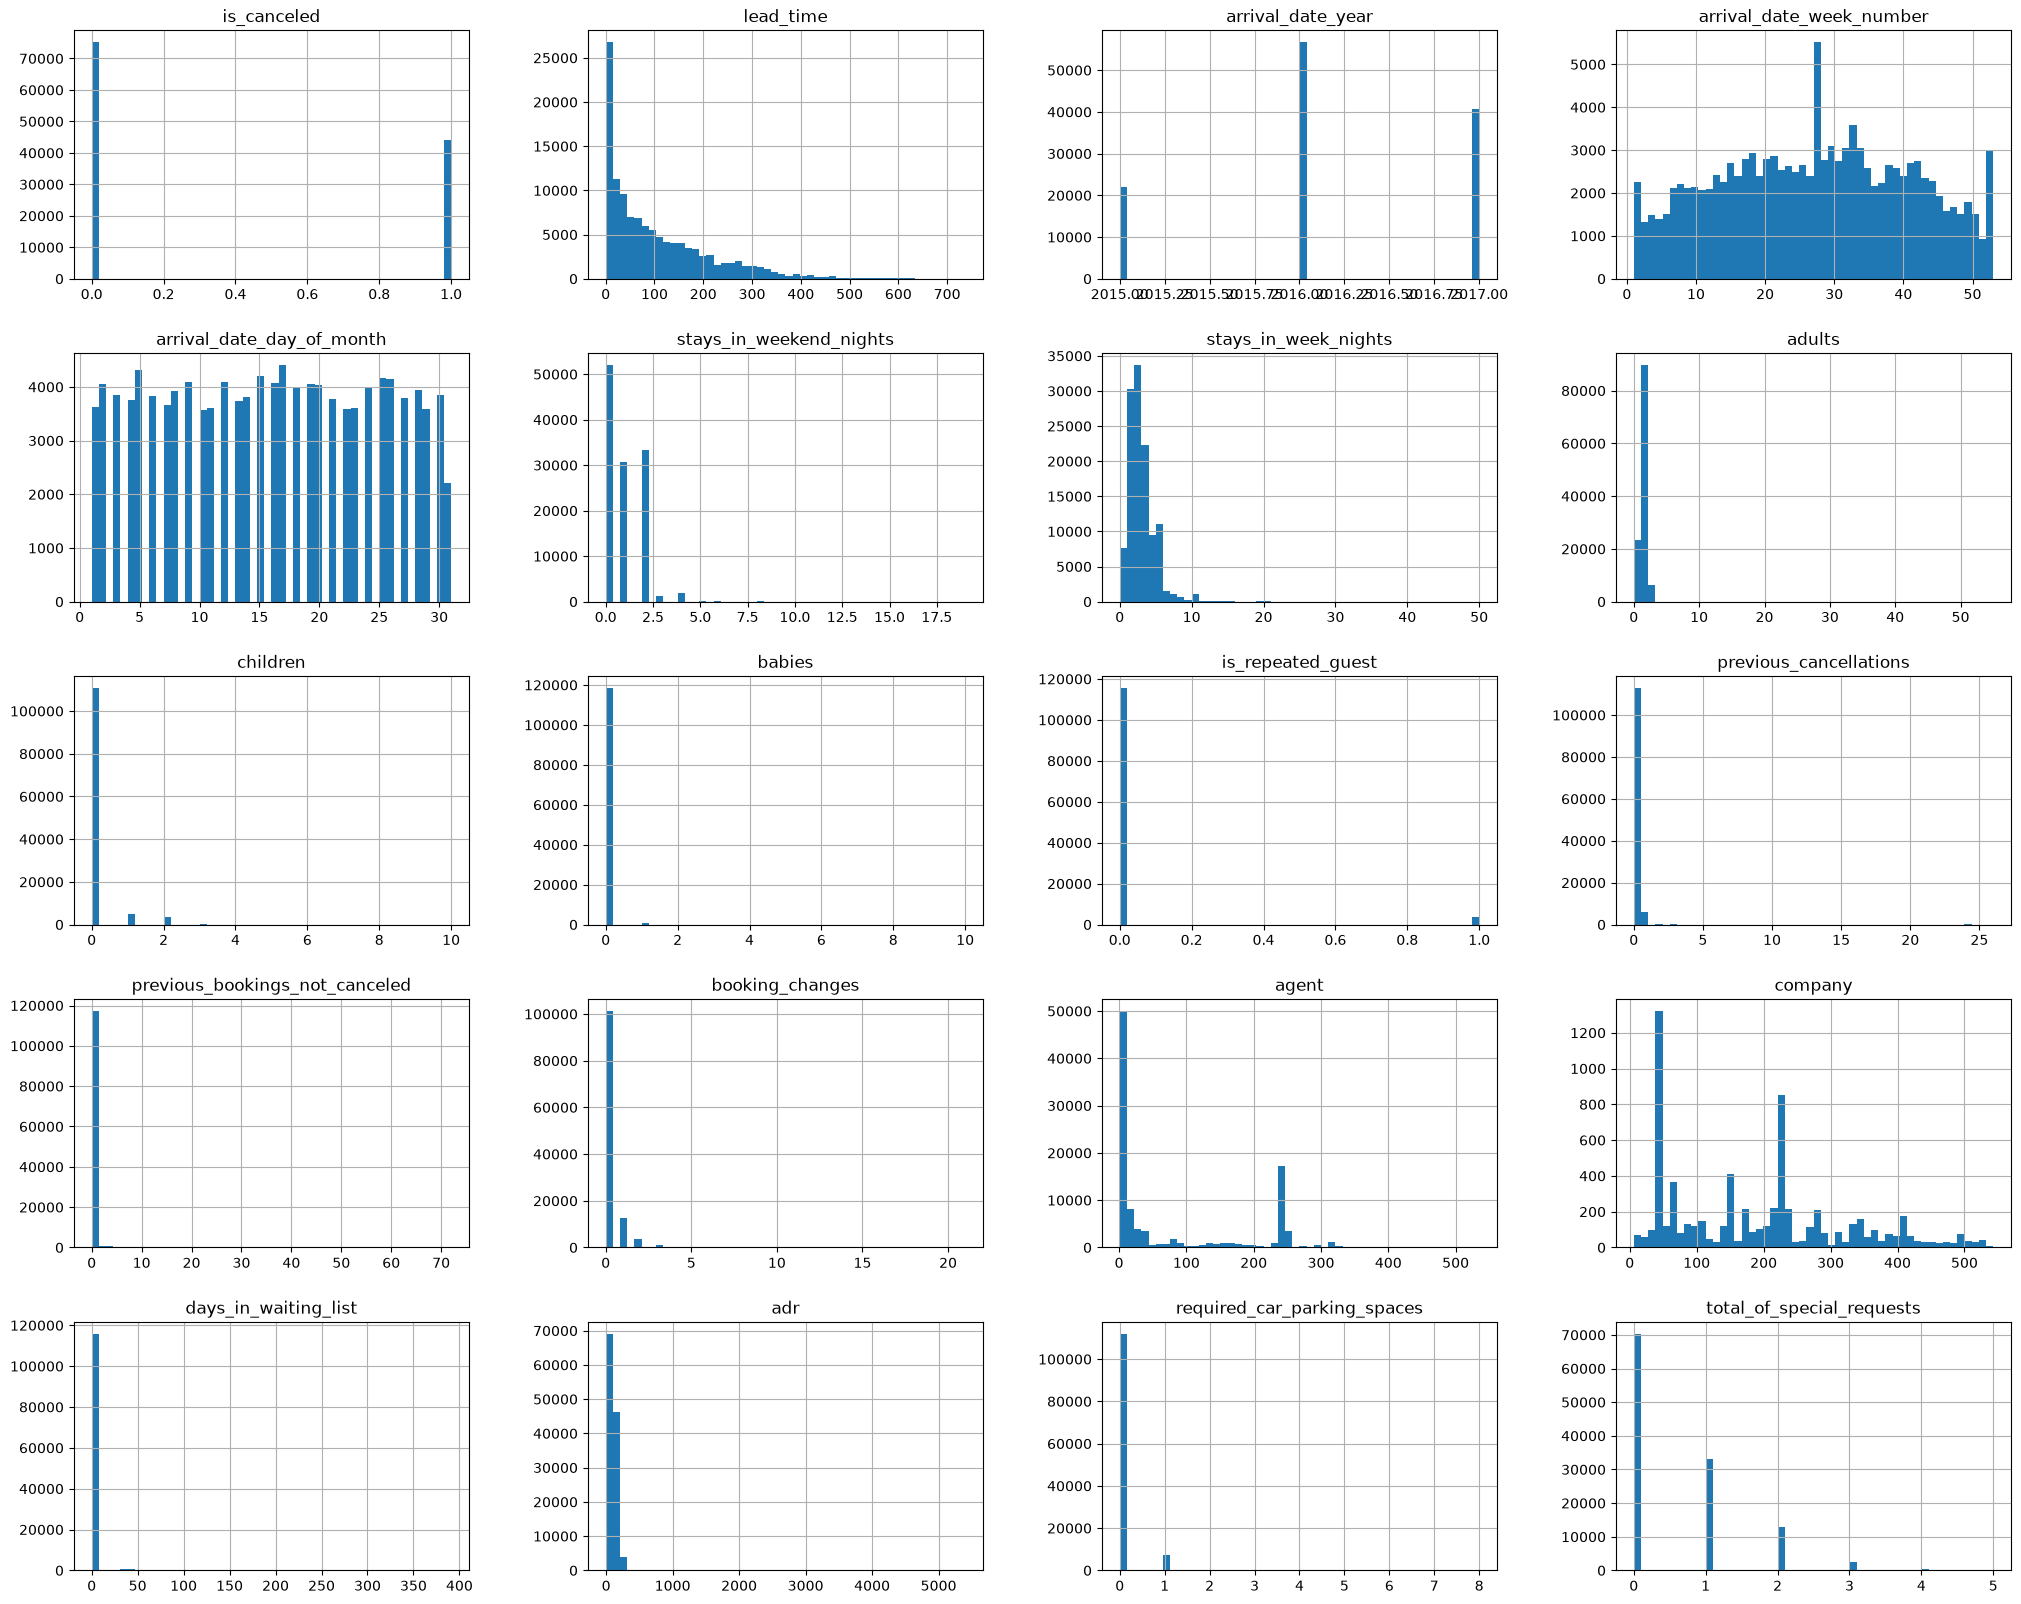

In [12]:
df.hist(bins=50, figsize=(25, 20))
plt.show()

### Correlation matrix

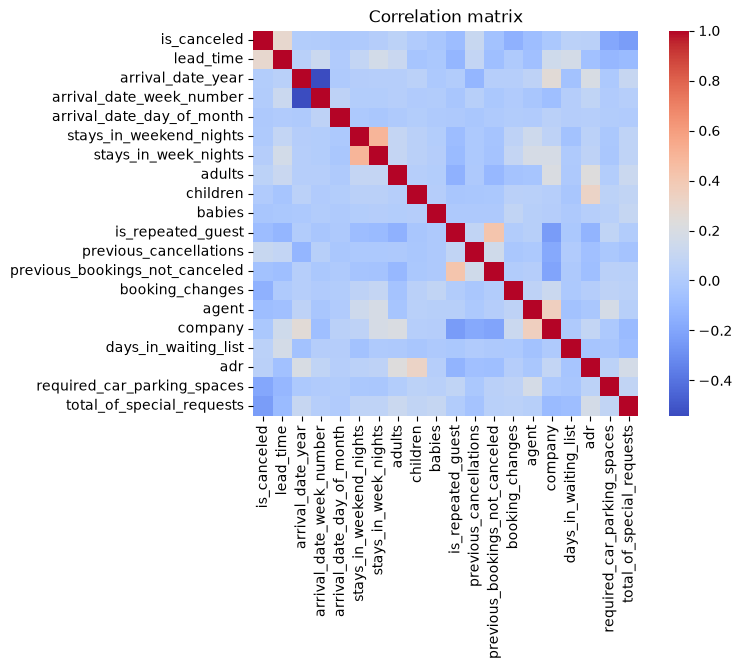

In [13]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', square=True)
plt.title("Correlation matrix")
plt.show()

### Heatmap

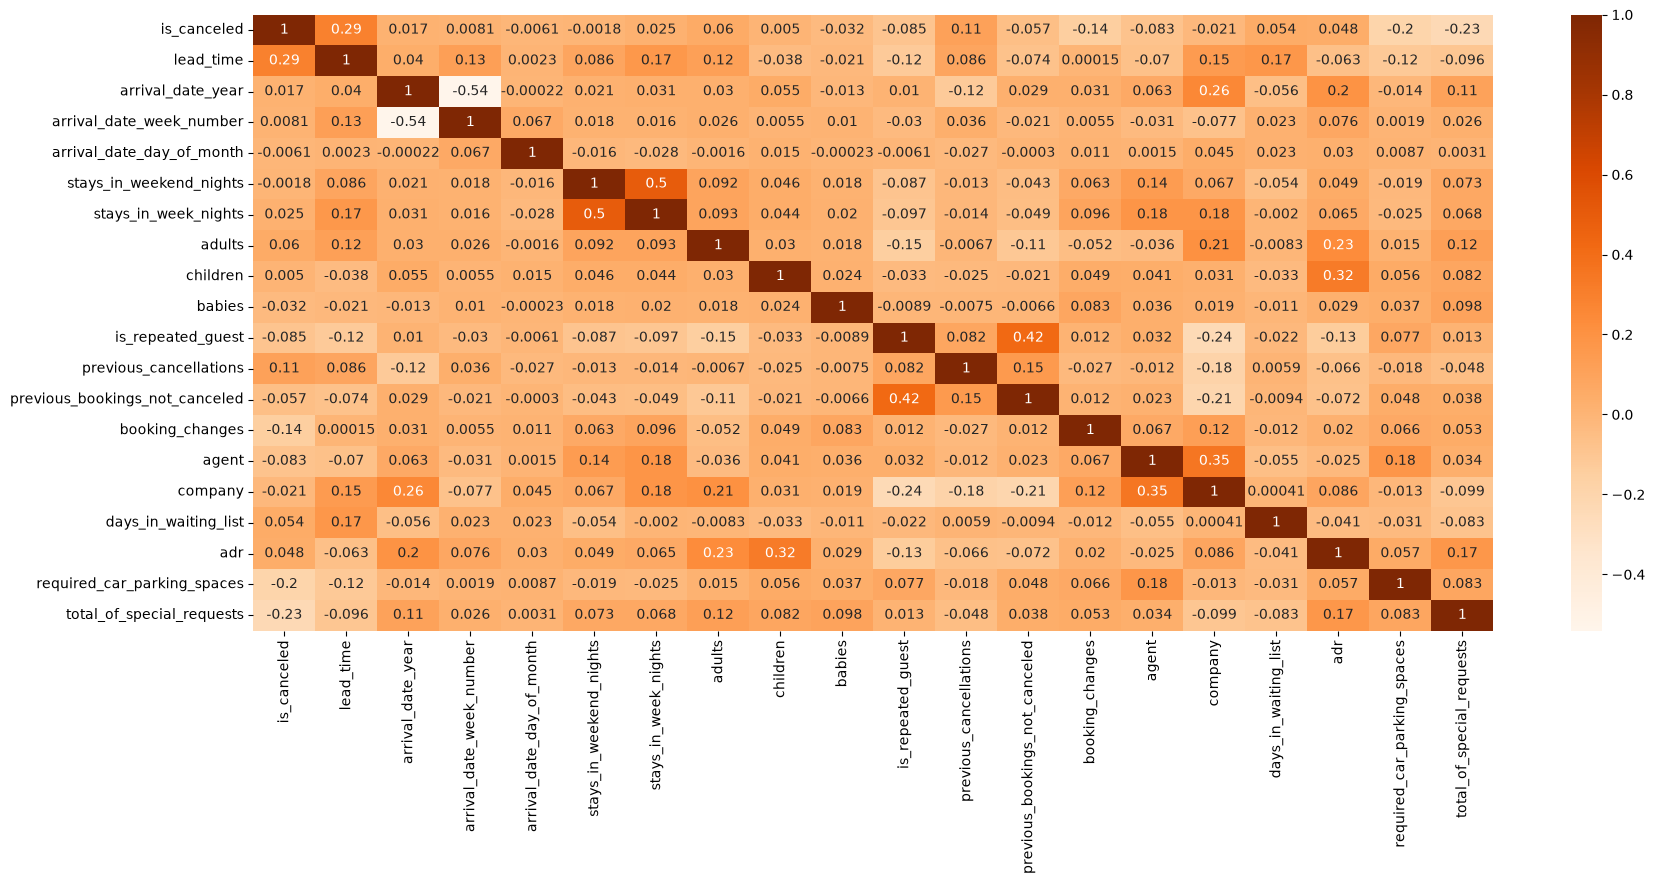

In [14]:
plt.figure(figsize=(20, 8))
hmp = df.corr(numeric_only=True)
sns.heatmap(hmp, cmap='Oranges', annot=True)
plt.show()

## Outliers

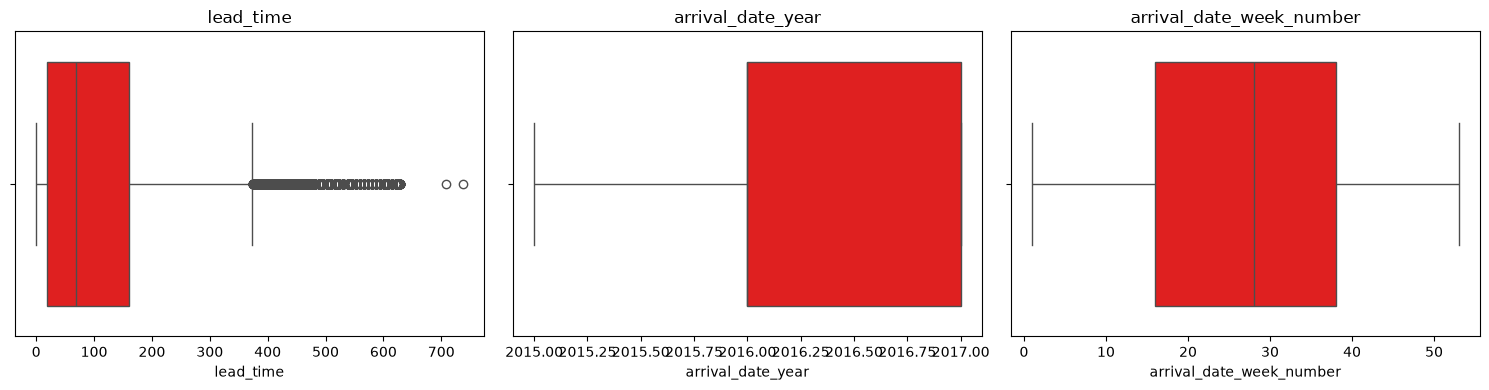

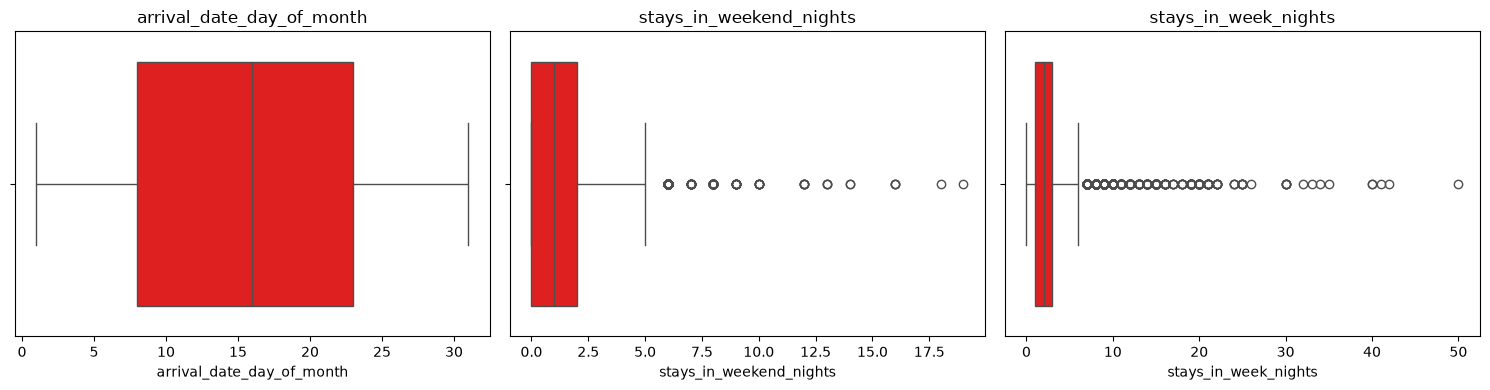

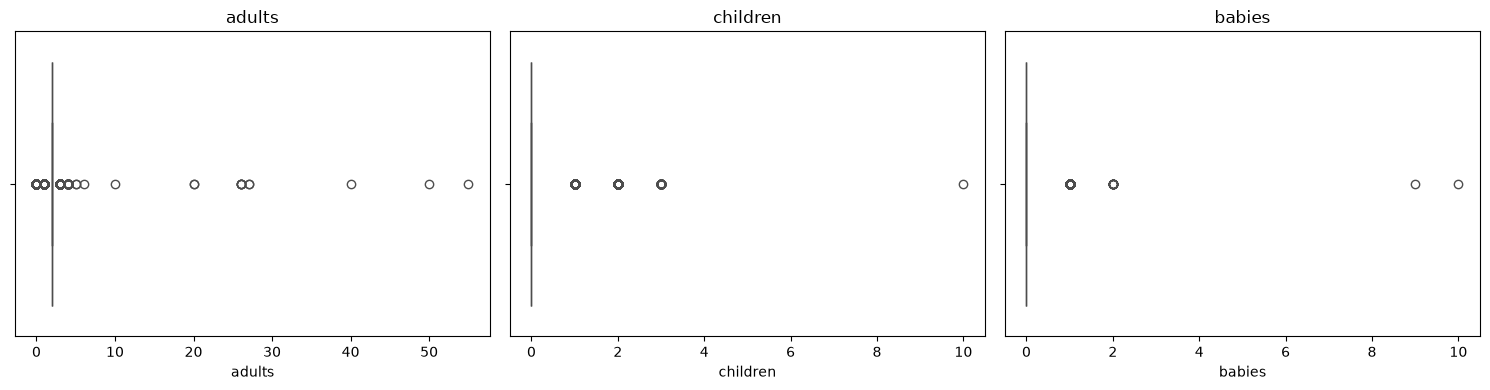

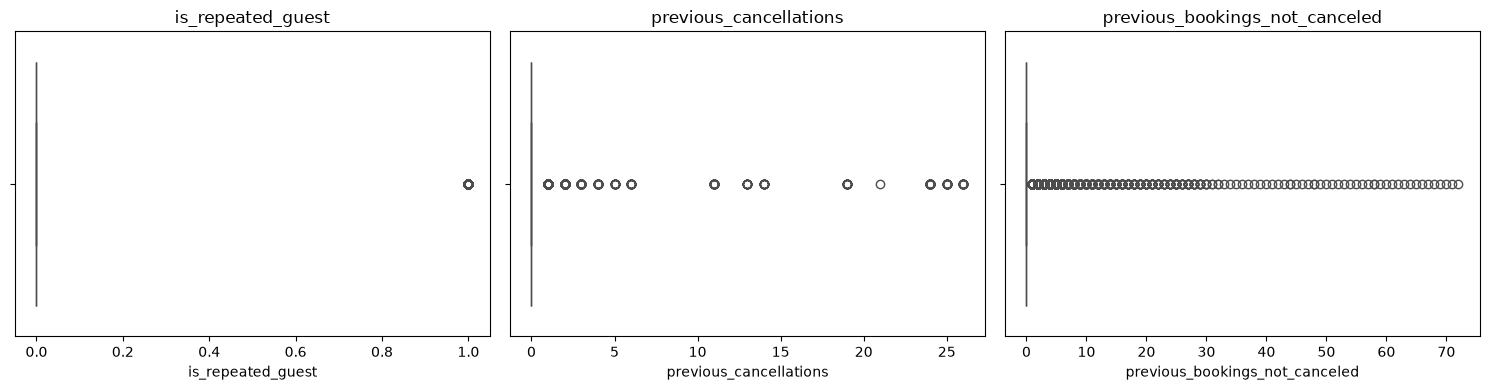

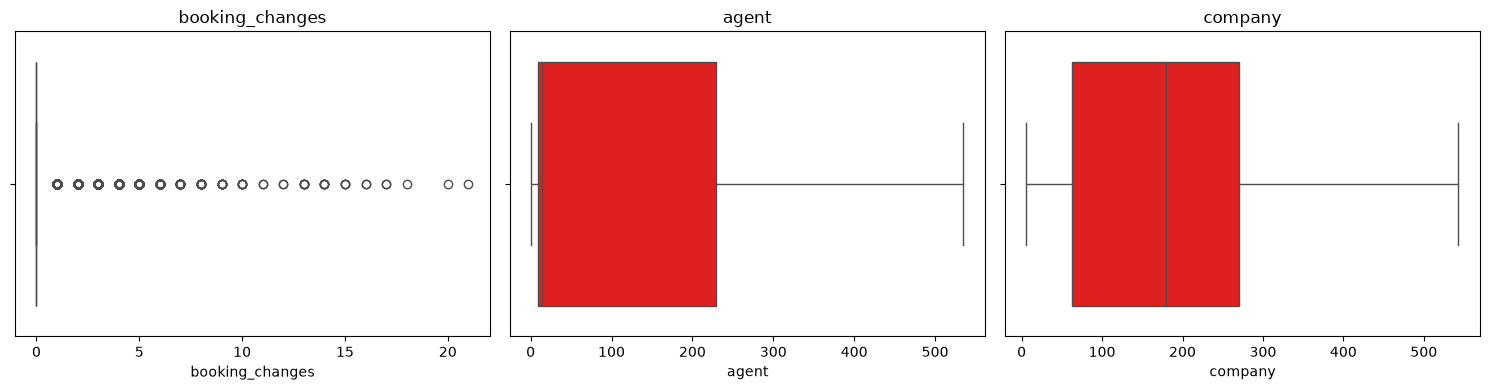

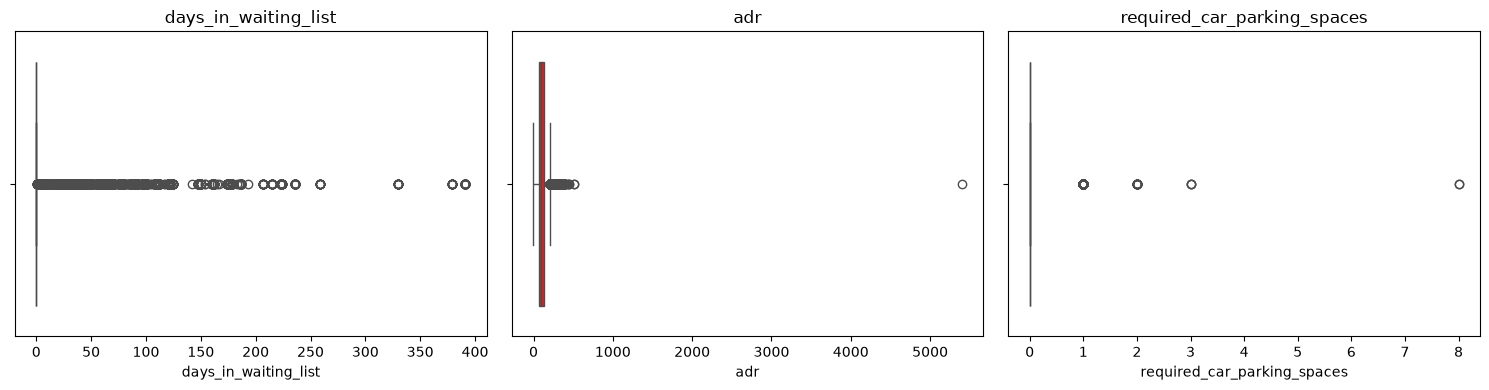

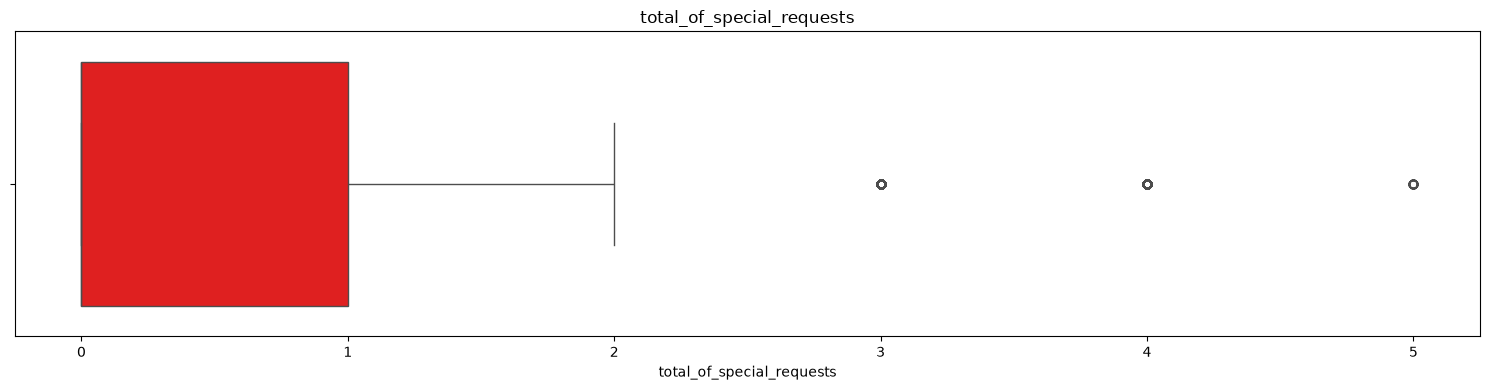

In [15]:
box_plt_cols = numerical_cols[1:]

n_cols = 3

for start in range(0, len(box_plt_cols), n_cols):
    cols = box_plt_cols[start:start + n_cols]

    fig, axes = plt.subplots(1, len(cols), figsize=(15, 4))

    axes = np.atleast_1d(axes)

    for ax, col in zip(axes, cols):
        sns.boxplot(x=df[col], color='red', ax=ax)
        ax.set_title(col)

    plt.tight_layout()
    plt.show()

    plt.close(fig)

## Advanced EDA

### ADR (Average Daily Rate) vs Lead time

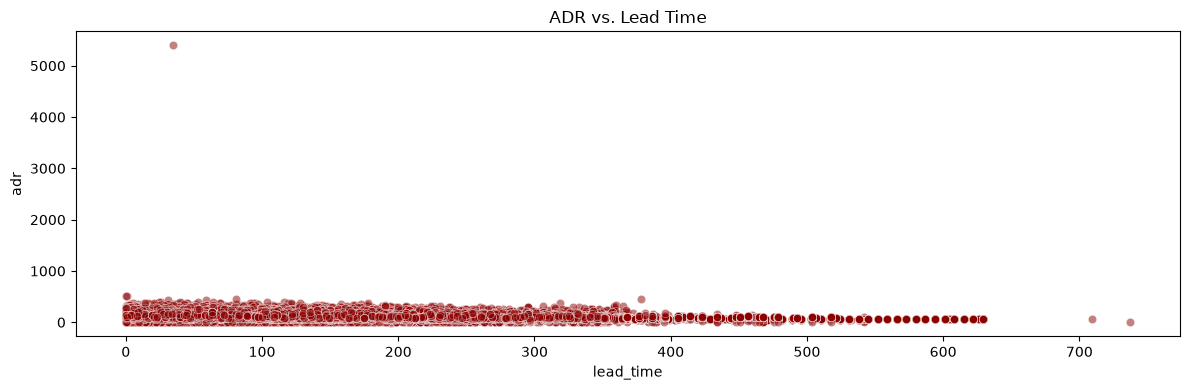

In [16]:
plt.figure(figsize=(12, 4))

plt.plot(1, 2, 2)
sns.scatterplot(data=df, x='lead_time', y='adr', alpha=0.5, color='darkred')
plt.title("ADR vs. Lead Time")

plt.tight_layout()
plt.show()

### Behavioral analysis

#### 1. Lead time vs Cancellation risk

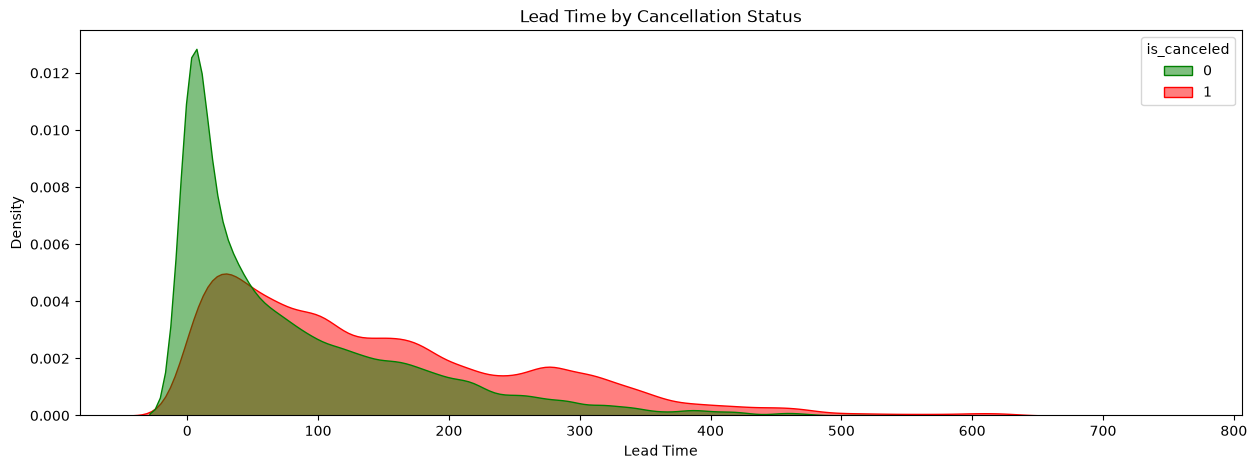

In [17]:
plt.figure(figsize=(15, 5))
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', fill=True, common_norm=False, palette={0: 'green', 1: 'red'}, alpha=0.5)
plt.title("Lead Time by Cancellation Status")
plt.xlabel("Lead Time")
plt.ylabel("Density")
plt.show()

#### 2. Total special requests vs Cancellation risk

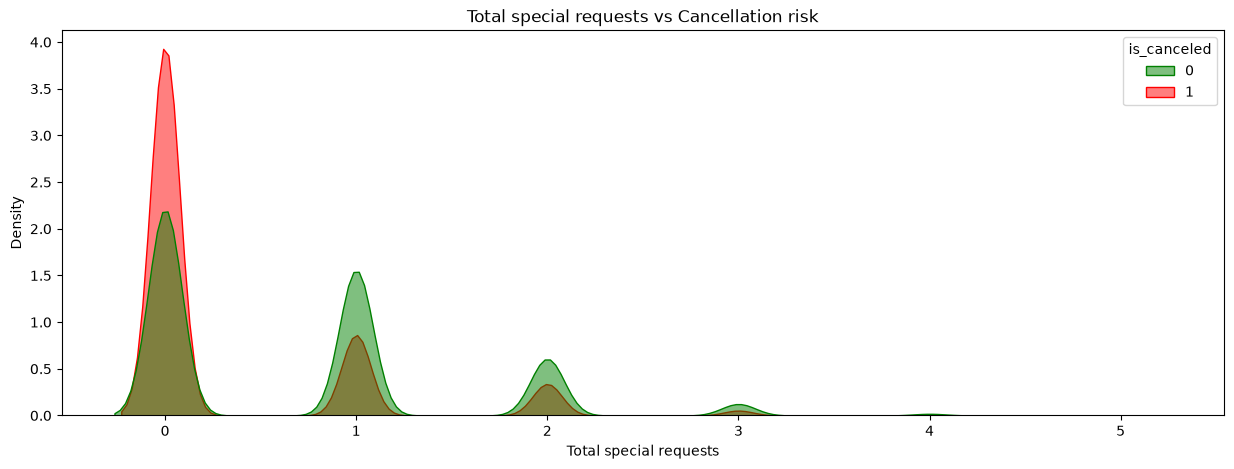

In [18]:
plt.figure(figsize=(15, 5))
sns.kdeplot(data=df, x='total_of_special_requests', hue='is_canceled', fill=True, common_norm=False, palette={0: 'green', 1: 'red'}, alpha=0.5)
plt.title("Total special requests vs Cancellation risk")
plt.xlabel("Total special requests")
plt.ylabel("Density")
plt.show()

#### 2. Average cancellation risk across month

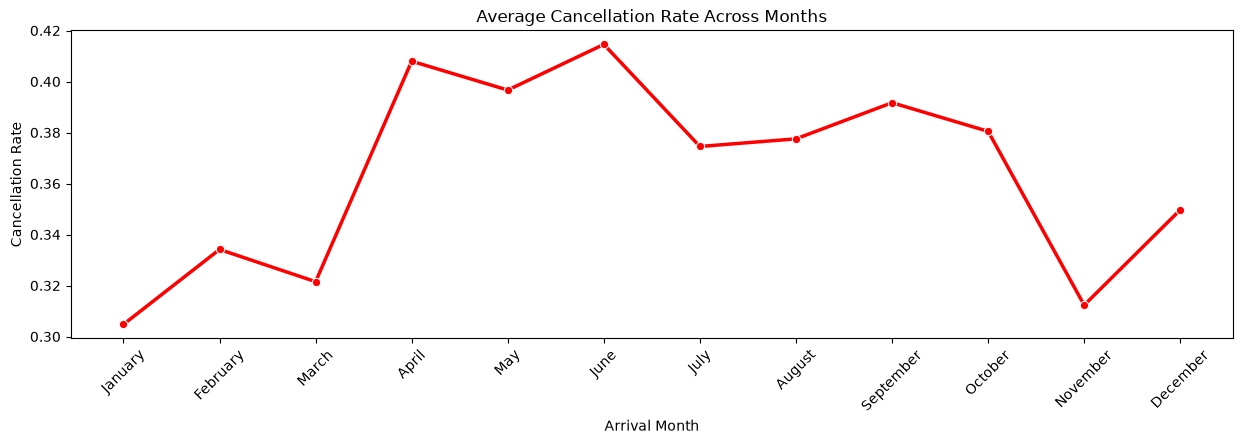

In [19]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

monthly_data = df.groupby('arrival_date_month')['is_canceled'].mean().loc[month_order].reset_index()

plt.figure(figsize=(15, 4))
sns.lineplot(data=monthly_data, x='arrival_date_month', y='is_canceled', marker='o', sort=False, color='red', linewidth=2.5)
plt.title("Average Cancellation Rate Across Months")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

#### 2. Average cancellation risk across years

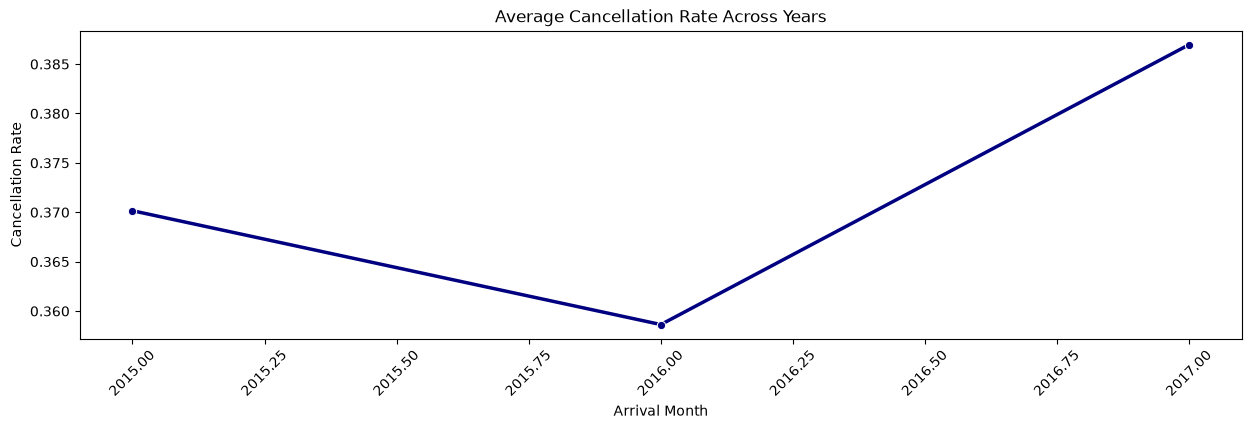

In [20]:
monthly_data = df.groupby('arrival_date_year')['is_canceled'].mean().reset_index()

plt.figure(figsize=(15, 4))
sns.lineplot(data=monthly_data, x='arrival_date_year', y='is_canceled', marker='o', sort=False, color='navy', linewidth=2.5)
plt.title("Average Cancellation Rate Across Years")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

#### 2. Average cancellation risk across day of the month

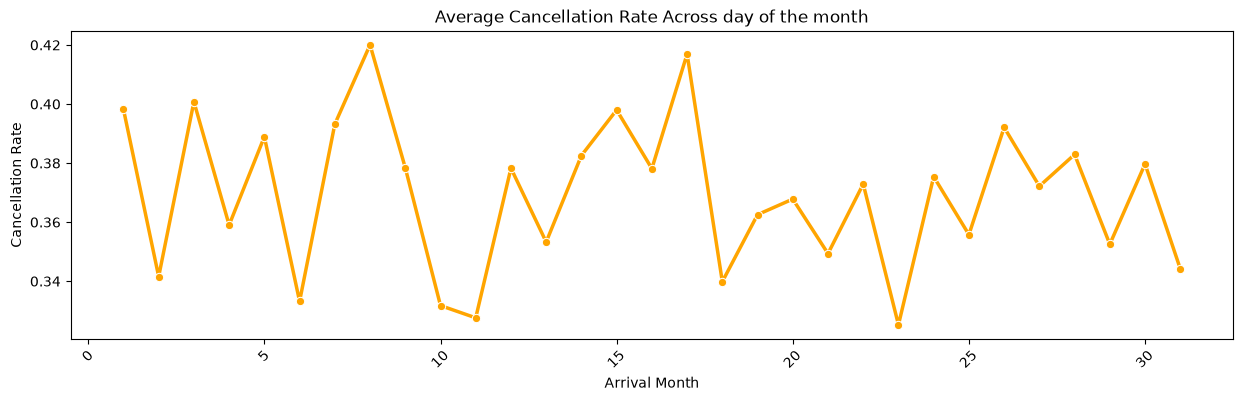

In [21]:
monthly_data = df.groupby('arrival_date_day_of_month')['is_canceled'].mean().reset_index()

plt.figure(figsize=(15, 4))
sns.lineplot(data=monthly_data, x='arrival_date_day_of_month', y='is_canceled', marker='o', sort=False, color='orange', linewidth=2.5)
plt.title("Average Cancellation Rate Across day of the month")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

#### 3. Cancellation with the hotelm type

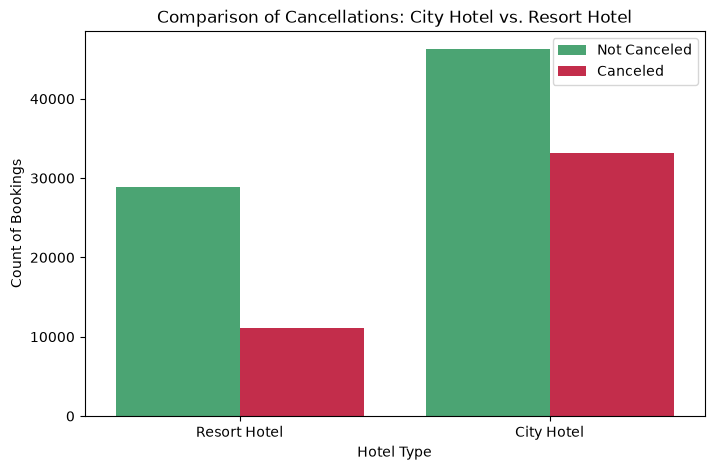

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='hotel', hue='is_canceled', palette={0: 'mediumseagreen', 1: 'crimson'})
plt.title("Comparison of Cancellations: City Hotel vs. Resort Hotel")
plt.xlabel("Hotel Type")
plt.ylabel("Count of Bookings")
plt.legend(['Not Canceled', 'Canceled'])
plt.show()

#### 4. Past Cancellations vs. Current Cancellation Probability

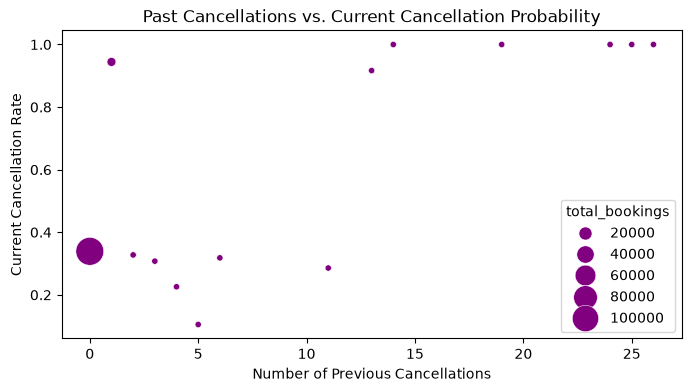

In [23]:
history_df = df.groupby('previous_cancellations').agg(
    total_bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean')
).reset_index()

plt.figure(figsize=(8, 4))
sns.scatterplot(data=history_df[history_df['total_bookings'] > 10], x='previous_cancellations', y='cancellation_rate', size='total_bookings', sizes=(20, 400), color='purple')
plt.title("Past Cancellations vs. Current Cancellation Probability")
plt.xlabel("Number of Previous Cancellations")
plt.ylabel("Current Cancellation Rate")
plt.show()